In [3]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })


detections_narrow_ET = pd.read_csv("./detection_output/narrow_ET.dat", sep="    ")
detections_narrow_ET_CE = pd.read_csv("./detection_output/narrow_ET_CE.dat", sep="    ")
detections_wide_ET = pd.read_csv("./detection_output/wide_ET.dat", sep="    ")
detections_wide_ET_CE = pd.read_csv("./detection_output/wide_ET_CE.dat", sep="    ")

df_narrow_gw = pd.read_csv("../gw/gw_params_narrow.dat", sep=" ")
df_wide_gw = pd.read_csv("../gw/gw_params_wide.dat", sep=" ")

df_narrow_kn = pd.read_csv("../kilonova/kn_params_narrow.dat", sep=" ")
df_wide_kn = pd.read_csv("../kilonova/kn_params_wide.dat", sep=" ")

df_narrow_grb = pd.read_csv("../grb/grb_params_narrow.dat", sep=" ")
df_wide_grb = pd.read_csv("../grb/grb_params_wide.dat", sep=" ")

/tmp/ipykernel_42911/2863722208.py:14: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  detections_narrow_ET = pd.read_csv("./detection_output/narrow_ET.dat", sep="    ")
/tmp/ipykernel_42911/2863722208.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  detections_narrow_ET_CE = pd.read_csv("./detection_output/narrow_ET_CE.dat", sep="    ")
/tmp/ipykernel_42911/2863722208.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine=

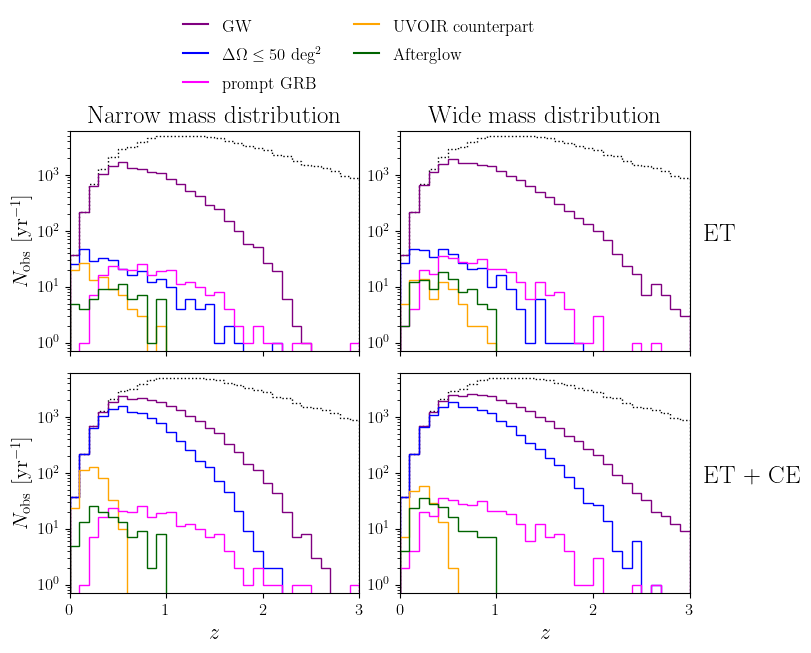

In [4]:
def plot_detections(ax, df):
    
    gw_detected = df["gw_detected"].astype(bool)
    grb_detected = df["grb_detected"].astype(bool)
    kn_detected = np.sum(df[["lsstg", "lssti", "ztfg", "ztfi", "ps1::i", "ps1::g", "ultrasat_custom"]], axis=1) >= 2
    sky_loc = df["DeltaOmega"] <= 50.
    afterglow_detected = np.sum(df[["radio_afterglow", "opt_afterglow", "xray_afterglow"]], axis=1) >= 1

    bins = np.linspace(0, 3, 31)
    ax.hist(df["redshift"], bins=bins, histtype = "step", color="black", linestyle="dotted")
    ax.hist(df["redshift"][gw_detected], bins=bins, histtype="step", color="purple", label="GW detections")
    ax.hist(df["redshift"][sky_loc], bins=bins, histtype="step", color="blue", label="$\\Delta\\Omega \\leq 100$ deg$^2$")
    ax.hist(df["redshift"][kn_detected], bins=bins, histtype="step", color="orange", label="KN detections")
    ax.hist(df["redshift"][grb_detected], bins=bins, histtype="step", color="magenta", label="GRB detections")
    ax.hist(df["redshift"][afterglow_detected], bins=bins, histtype="step", color="darkgreen", label="Afterglow detections")

    ax.set_yscale("log")
    ax.set_ylim((0.7, 6e3))
    ax.set_xlim((0, 3))



fig, ax = plt.subplots(2, 2, figsize= (8, 6), sharex=True)
fig.subplots_adjust(hspace=0.1, wspace=0.14)

ax[0,0].set_title("Narrow mass distribution", fontsize=18)
ax[0,0].set_ylabel("$N_{\\mathrm{obs}}$ [yr$^{-1}$]", fontsize=15)
plot_detections(ax[0,0], detections_narrow_ET)

ax[0,1].set_title("Wide mass distribution", fontsize=18)
ax[0,1].text(1.05, 0.5, "ET", rotation=0, transform=ax[0,1].transAxes, fontsize=18)
plot_detections(ax[0,1], detections_wide_ET)


plot_detections(ax[1,0], detections_narrow_ET_CE)
ax[1,0].set_ylabel("$N_{\\mathrm{obs}}$ [yr$^{-1}$]", fontsize=15)
ax[1,0].set_xlabel("$z$", fontsize=16)


plot_detections(ax[1,1], detections_wide_ET_CE)
ax[1,1].set_xlabel("$z$", fontsize=16)
ax[1,1].text(1.05, 0.5, "ET + CE", rotation=0, transform=ax[1,1].transAxes, fontsize=18)



labels = [r"GW", r"$\Delta\Omega\leq50$ deg$^2$", "prompt GRB", "UVOIR counterpart", "Afterglow"]

lc1 = plt.plot([], [], color="purple")[0]
lc2 = plt.plot([], [], color="blue")[0]
lc3 = plt.plot([], [], color="magenta")[0]
lc4 = plt.plot([], [], color="orange")[0]
lc5 = plt.plot([], [], color="darkgreen",)[0]
ax[0,0].legend([lc1, lc2, lc3, lc4, lc5], 
                labels, 
                handlelength=1.5, handleheight=1.5,
                bbox_to_anchor=[1., 1.1],loc='lower center',frameon=False, ncol=2)

fig.savefig("../../figures/detections.pdf", dpi=250, bbox_inches="tight")

In [5]:
filts = ["ztfg", "ztfi", "ps1::g", "ps1::i", "lsstg", "lssti", "ultrasat_custom"]

kn_narrow_ET = np.sum(np.sum(detections_narrow_ET[filts], axis=1) >= 2)
kn_narrow_ET_CE = np.sum(np.sum(detections_narrow_ET_CE[filts], axis=1) >= 2)
kn_wide_ET = np.sum(np.sum(detections_wide_ET[filts], axis=1) >= 2)
kn_wide_ET_CE = np.sum(np.sum(detections_wide_ET_CE[filts], axis=1) >= 2)

afgs = ["radio_afterglow", "opt_afterglow", "xray_afterglow"]
afg_narrow_ET = np.sum(np.sum(detections_narrow_ET[afgs], axis=1) >= 1)
afg_narrow_ET_CE = np.sum(np.sum(detections_narrow_ET_CE[afgs], axis=1) >= 1)
afg_wide_ET = np.sum(np.sum(detections_wide_ET[afgs], axis=1) >= 1)
afg_wide_ET_CE = np.sum(np.sum(detections_narrow_ET_CE[afgs], axis=1) >= 1)

def afterglow_count(detection_df, afgpy_type: str):
    kn_detected = np.sum(detection_df[["lssti", "lsstg", "ps1::g", "ps1::i", "ztfg", "ztfi", "ultrasat_custom"]], axis=1) >=2
    return f"{np.sum(detection_df[afgpy_type]>0)}~({np.sum(detection_df[afgpy_type][~kn_detected]>0)})"

with open("table.tex", "w") as out:

    out.write("\\toprule \n\\toprule \n")
    out.write("Event & Band & \\SetCell[c=2]{c} Narrow & & \\SetCell[c=2]{c} Wide & \\\\ \n")
    out.write(" & & ET & ET+CE & ET & ET+CE \\\\ \n ")
    out.write("\\midrule \n")
    
    # GRB
    out.write(f"\\SetCell[r=3]{{c}} GRB & Fermi/GBM & \\SetCell[c=2]{{c}} {np.sum(df_narrow_grb["fermi_detected"])} &  & \\SetCell[c=2]{{c}} {np.sum(df_wide_grb["fermi_detected"])} \\\\ \n")
    out.write(f" & Swift/BAT & \\SetCell[c=2]{{c}} {np.sum(df_narrow_grb["swift_detected"])} &  & \\SetCell[c=2]{{c}} {np.sum(df_wide_grb["swift_detected"])} \\\\ \n")
    out.write(f" & GECAM & \\SetCell[c=2]{{c}} {np.sum(df_narrow_grb["gecam_detected"])} &  & \\SetCell[c=2]{{c}} {np.sum(df_wide_grb["gecam_detected"])} \\\\ \n")

    # GW 
    out.write(f"\\midrule \n")
    out.write(f" GW & - & {np.sum(detections_narrow_ET["gw_detected"])} & {np.sum(detections_narrow_ET_CE["gw_detected"])} & {np.sum(detections_wide_ET["gw_detected"])} & {np.sum(detections_wide_ET_CE["gw_detected"])} \\\\ \n")

    # UVOIR
    out.write(f"\\midrule \n")
    out.write(f"\\SetCell[r=8]{{c}} GW + UVOIR & Rubin $g$ & {np.sum(detections_narrow_ET["lsstg"]>=1)} & {np.sum(detections_narrow_ET_CE["lsstg"]>=1)} & {np.sum(detections_wide_ET["lsstg"]>=1)} & {np.sum(detections_wide_ET_CE["lsstg"]>=1)} \\\\ \n")
    out.write(f" & Rubin $i$ & {np.sum(detections_narrow_ET["lssti"]>=1)} & {np.sum(detections_narrow_ET_CE["lssti"]>=1)} & {np.sum(detections_wide_ET["lssti"]>=1)} & {np.sum(detections_wide_ET_CE["lssti"]>=1)} \\\\ \n")
    out.write(f" & PSTARRS~$g$ & {np.sum(detections_narrow_ET["ps1::g"]>=1)} & {np.sum(detections_narrow_ET_CE["ps1::g"]>=1)} & {np.sum(detections_wide_ET["ps1::g"]>=1)} & {np.sum(detections_wide_ET_CE["ps1::g"]>=1)} \\\\ \n")
    out.write(f" & PSTARRS~$i$ & {np.sum(detections_narrow_ET["ps1::i"]>=1)} & {np.sum(detections_narrow_ET_CE["ps1::i"]>=1)} & {np.sum(detections_wide_ET["ps1::i"]>=1)} & {np.sum(detections_wide_ET_CE["ps1::i"]>=1)} \\\\ \n")
    out.write(f" & ZTF $g$ & {np.sum(detections_narrow_ET["ztfg"]>=1)} & {np.sum(detections_narrow_ET_CE["ztfg"]>=1)} & {np.sum(detections_wide_ET["ztfg"]>=1)} & {np.sum(detections_wide_ET_CE["ztfg"]>=1)} \\\\ \n")
    out.write(f" & ZTF $i$ & {np.sum(detections_narrow_ET["ztfi"]>=1)} & {np.sum(detections_narrow_ET_CE["ztfi"]>=1)} & {np.sum(detections_wide_ET["ztfi"]>=1)} & {np.sum(detections_wide_ET_CE["ztfi"]>=1)} \\\\ \n")
    out.write(f" & ULTRASAT & {np.sum(detections_narrow_ET["ultrasat_custom"]>=1)} & {np.sum(detections_narrow_ET_CE["ultrasat_custom"]>=1)} & {np.sum(detections_wide_ET["ultrasat_custom"]>=1)} & {np.sum(detections_wide_ET_CE["ultrasat_custom"]>=1)} \\\\ \n")
    out.write(f" & \\textbf{{Combined}} & {kn_narrow_ET} & {kn_narrow_ET_CE} & {kn_wide_ET} & {kn_wide_ET_CE} \\\\ \n")

    # Afterglow
    out.write(f"\\midrule \n")
    out.write(f"\\SetCell[r=4]{{c}} GW + Afterglow & radio & {afterglow_count(detections_narrow_ET, "radio_afterglow")} & {afterglow_count(detections_narrow_ET_CE, "radio_afterglow")} & {afterglow_count(detections_wide_ET, "radio_afterglow")} & {afterglow_count(detections_wide_ET_CE, "radio_afterglow")} \\\\ \n")
    out.write(f" & optical & {afterglow_count(detections_narrow_ET, "opt_afterglow")} & {afterglow_count(detections_narrow_ET_CE, "opt_afterglow")} & {afterglow_count(detections_wide_ET, "opt_afterglow")} & {afterglow_count(detections_wide_ET_CE, "opt_afterglow")} \\\\ \n")
    out.write(f" & X-ray & {afterglow_count(detections_narrow_ET, "xray_afterglow")} & {afterglow_count(detections_narrow_ET_CE, "xray_afterglow")} & {afterglow_count(detections_wide_ET, "xray_afterglow")} & {afterglow_count(detections_wide_ET_CE, "xray_afterglow")} \\\\ \n")
    out.write(f" & \\textbf{{Combined}} & {afg_narrow_ET} & {afg_narrow_ET_CE} & {afg_wide_ET} & {afg_wide_ET_CE} \\\\ \n")
    out.write("\\bottomrule \n")

In [6]:
detections_narrow_ET.head()

,redshift,gw_detected,grb_detected,DeltaOmega,telt_vr,lsstg,lssti,telt_ztf,ztfg,ztfi,telt_pstarrs,ps1::g,ps1::i,telt_ultrasat,ultrasat_custom,radio_afterglow,opt_afterglow,xray_afterglow,telt_vr_afterglow
0,1.330,0,0,inf,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0,0.0
1,1.393,0,0,inf,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0,0.0
2,0.833,0,0,inf,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0,0.0
3,1.622,0,0,inf,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0,0.0
4,2.266,0,0,inf,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0,0.0


In [13]:
with open("table_telescopetime.tex", "w") as out:

    out.write("\\toprule \n\\toprule \n")
    out.write("Telescope & \\SetCell[c=2]{c} Narrow & & \\SetCell[c=2]{c} Wide & \\\\ \n")
    out.write(" & ET & ET+CE & ET & ET+CE \\\\ \n ")
    out.write("\\midrule \n")
    
    # UVOIR
    out.write(f"\\midrule \n")
    out.write(f"Rubin & {np.sum(detections_narrow_ET["telt_vr"])/(3.65*0.5):.2f} & {np.sum(detections_narrow_ET_CE["telt_vr"])/(3.65*0.5):.2f} & {np.sum(detections_wide_ET["telt_vr"])/(3.65*0.5):.2f} & {np.sum(detections_wide_ET_CE["telt_vr"]) /(3.65*0.5):.2f} \\\\ \n")
    out.write(f"PSTARRS & {np.sum(detections_narrow_ET["telt_pstarrs"])/(3.65*0.5) :.2f} & {np.sum(detections_narrow_ET_CE["telt_pstarrs"])/(3.65*0.5):.2f} & {np.sum(detections_wide_ET["telt_pstarrs"])/(3.65*0.5):.2f} & {np.sum(detections_wide_ET_CE["telt_pstarrs"]) / (3.65*0.5):.2f} \\\\ \n")
    out.write(f"ZTF & {np.sum(detections_narrow_ET["telt_ztf"])/(3.65*0.5):.2f} & {np.sum(detections_narrow_ET_CE["telt_ztf"])/(3.65*0.5):.2f} & {np.sum(detections_wide_ET["telt_ztf"])/(3.65*0.5):.2f} & {np.sum(detections_wide_ET_CE["telt_ztf"]) / (3.65*0.5):.2f} \\\\ \n")
    out.write(f"ULTRASAT & {np.sum(detections_narrow_ET["telt_ultrasat"])/(3.65):.2f} & {np.sum(detections_narrow_ET_CE["telt_ultrasat"])/(3.65):.2f} & {np.sum(detections_wide_ET["telt_ultrasat"])/(3.65):.2f} & {np.sum(detections_wide_ET_CE["telt_ultrasat"])/ 3.65:.2f} \\\\ \n")

    out.write("\\bottomrule \n")

In [14]:
def print_DeltaOmega_quantiles(detection_df):
    mask = detection_df["gw_detected"].astype(bool)

    print(np.quantile(detection_df["DeltaOmega"][mask], q=[0.5, 0.9]))

print_DeltaOmega_quantiles(detections_narrow_ET_CE)
print_DeltaOmega_quantiles(detections_wide_ET_CE)

print(np.sum(detections_narrow_ET["DeltaOmega"]<=50.31)/ np.sum(detections_narrow_ET["gw_detected"]), np.sum(detections_narrow_ET["DeltaOmega"]<=127.915)/ np.sum(detections_narrow_ET["gw_detected"])) 
print(np.sum(detections_wide_ET["DeltaOmega"]<=48.56)/ np.sum(detections_wide_ET["gw_detected"]), np.sum(detections_wide_ET["DeltaOmega"]<=126.982)/np.sum(detections_wide_ET["gw_detected"])) 

[ 50.31  127.866]
[ 48.55  126.904]
0.021146899458157738 0.04425045153521975
0.02040816326530612 0.03943272224143895


(0.0, 1.0)

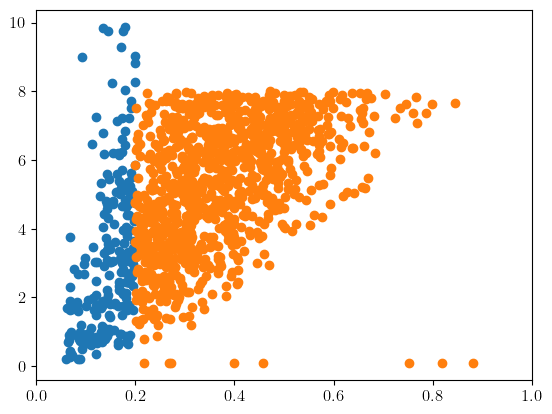

In [121]:
noinfs = (detections_wide_ET_CE["DeltaOmega"] <=10.) & (detections_wide_ET_CE["redshift"] <= 0.2)
plt.scatter(detections_wide_ET_CE["redshift"][noinfs], detections_wide_ET_CE["DeltaOmega"][noinfs])

mask2 =  (detections_wide_ET_CE["DeltaOmega"]<=8.) & (0.2<= detections_wide_ET_CE["redshift"]) & (detections_wide_ET_CE["redshift"]<=1)
plt.scatter(detections_wide_ET_CE["redshift"][mask2], detections_wide_ET_CE["DeltaOmega"][mask2])

plt.xlim((0,1))

In [122]:
np.sum(noinfs | mask2)

np.int64(1197)